In [1]:
import pandas as pd
import os

csv_path = "Data_Entry_2017.csv"

image_folder = "images"

df = pd.read_csv(csv_path)

df = df[['Image Index', 'Finding Labels', 'View Position']].copy()

df = df[df['View Position'] == 'PA'].reset_index(drop=True)

df['Finding Labels'] = df['Finding Labels'].str.split('|')

df = df.explode('Finding Labels').reset_index(drop=True)

df['image_path'] = df['Image Index'].apply(lambda x: os.path.join(image_folder, x))

print(df.head())
print(len(df))


        Image Index Finding Labels View Position               image_path
0  00000001_000.png   Cardiomegaly            PA  images\00000001_000.png
1  00000001_001.png   Cardiomegaly            PA  images\00000001_001.png
2  00000001_001.png      Emphysema            PA  images\00000001_001.png
3  00000001_002.png   Cardiomegaly            PA  images\00000001_002.png
4  00000001_002.png       Effusion            PA  images\00000001_002.png
81630


In [2]:
# Number of unique classes
num_classes = df['Finding Labels'].nunique()
print("Total number of classes:", num_classes)

# Count how many images per class
class_counts = df['Finding Labels'].value_counts()

print("\nImages per class:")
print(class_counts)


Total number of classes: 15

Images per class:
Finding Labels
No Finding            39302
Infiltration           9353
Effusion               6589
Atelectasis            5728
Nodule                 4177
Mass                   3567
Pneumothorax           3407
Pleural_Thickening     2418
Cardiomegaly           1563
Consolidation          1521
Emphysema              1499
Fibrosis               1408
Pneumonia               630
Edema                   276
Hernia                  192
Name: count, dtype: int64


In [3]:
df = df[df['Finding Labels'] != 'Hernia'].reset_index(drop=True)
df = df[df['Finding Labels'] != 'Edema'].reset_index(drop=True)
df = df[df['Finding Labels'] != 'Pneumonia'].reset_index(drop=True)

In [4]:
import pandas as pd
counts = df['Finding Labels'].value_counts()
print("Current class counts:\n", counts, "\n")

no_finding_count = counts['No Finding']
other_max = counts.drop('No Finding').max()  
target = int(min(no_finding_count, other_max)) 

print(f"Downsampling 'No Finding' from {no_finding_count} to {target} (match next-largest class)\n")

no_finding_rows = df[df['Finding Labels'] == 'No Finding']
sampled_no_finding = no_finding_rows.sample(n=target, random_state=42)

other_rows = df[df['Finding Labels'] != 'No Finding']

df_downsampled = pd.concat([other_rows, sampled_no_finding], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

new_counts = df_downsampled['Finding Labels'].value_counts()
print("New class counts:\n", new_counts)


Current class counts:
 Finding Labels
No Finding            39302
Infiltration           9353
Effusion               6589
Atelectasis            5728
Nodule                 4177
Mass                   3567
Pneumothorax           3407
Pleural_Thickening     2418
Cardiomegaly           1563
Consolidation          1521
Emphysema              1499
Fibrosis               1408
Name: count, dtype: int64 

Downsampling 'No Finding' from 39302 to 9353 (match next-largest class)

New class counts:
 Finding Labels
Infiltration          9353
No Finding            9353
Effusion              6589
Atelectasis           5728
Nodule                4177
Mass                  3567
Pneumothorax          3407
Pleural_Thickening    2418
Cardiomegaly          1563
Consolidation         1521
Emphysema             1499
Fibrosis              1408
Name: count, dtype: int64


In [5]:
import cv2, os, numpy as np, pandas as pd
labels = sorted(df_downsampled['Finding Labels'].unique())
label_map = {lab: i for i, lab in enumerate(labels)}
class_image_dict = {}
for lab in labels:
    paths = df_downsampled.loc[df_downsampled['Finding Labels'] == lab, 'image_path'].unique().tolist()
    class_image_dict[lab] = paths

X, y = [], []
for lab, image_paths in class_image_dict.items():
    for image_path in image_paths:
        img = cv2.imread(image_path)
        if img is None:
            continue
        img = cv2.resize(img, (224, 224))
        X.append(img)
        y.append(label_map[lab])

X = np.array(X, dtype=np.uint8)
y = np.array(y, dtype=np.uint8)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("label_map:", label_map)


X shape: (50583, 224, 224, 3)
y shape: (50583,)
label_map: {'Atelectasis': 0, 'Cardiomegaly': 1, 'Consolidation': 2, 'Effusion': 3, 'Emphysema': 4, 'Fibrosis': 5, 'Infiltration': 6, 'Mass': 7, 'No Finding': 8, 'Nodule': 9, 'Pleural_Thickening': 10, 'Pneumothorax': 11}


In [6]:
import numpy as np

np.save("X.npy", X)
np.save("y.npy", y)

In [22]:
import numpy as np

X = np.load("X.npy")
y = np.load("y.npy")


In [ ]:
# single_label_training.py

import numpy as np
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split

# -------------------------------------------------------
# Load arrays
# -------------------------------------------------------
X = np.load('X.npy')      # shape (N,H,W,3)
y = np.load('y.npy')      # shape (N,)

X = X.astype(np.uint8)
y = y.astype(np.int64)

# -------------------------------------------------------
# Train/val split
# -------------------------------------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

# -------------------------------------------------------
# Dataset
# -------------------------------------------------------
class NumpyImageDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X, self.y = X, y
        self.transform = transform

    def __len__(self): 
        return len(self.X)

    def __getitem__(self, idx):
        img = self.X[idx]     # H,W,3 uint8
        label = int(self.y[idx])

        from PIL import Image
        img = Image.fromarray(img)

        if self.transform:
            img = self.transform(img)

        return img, label

# -------------------------------------------------------
# Transforms
# -------------------------------------------------------
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

val_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

train_ds = NumpyImageDataset(X_train, y_train, transform=train_tf)
val_ds = NumpyImageDataset(X_val, y_val, transform=val_tf)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=4)

# -------------------------------------------------------
# MODEL (CHANGE ONLY THIS BLOCK)
# -------------------------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

num_classes = len(np.unique(y))

### --- OPTION 1: RESNET50 (recommended if you want ResNet) ---
# model = models.resnet50(pretrained=True)
# model.fc = nn.Linear(model.fc.in_features, num_classes)

### --- OPTION 2: EFFICIENTNET-B0 ---
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

# -------------------------------------------------------
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2)

# -------------------------------------------------------
# Training loop
# -------------------------------------------------------
for epoch in range(12):

    # ---- TRAIN ----
    model.train()
    train_loss = 0.0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * imgs.size(0)

    train_loss /= len(train_loader.dataset)

    # ---- VAL ----
    model.eval()
    val_loss = 0.0
    correct = 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            out = model(imgs)
            loss = criterion(out, labels)
            val_loss += loss.item() * imgs.size(0)

            preds = out.argmax(dim=1)
            correct += (preds == labels).sum().item()

    val_loss /= len(val_loader.dataset)
    val_acc = correct / len(val_loader.dataset)

    scheduler.step(val_loss)

    print(f"Epoch {epoch}: train_loss {train_loss:.4f} | val_loss {val_loss:.4f} | val_acc {val_acc:.4f}")


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth



00%|██████████| 20.5M/20.5M [00:00<00:00, 83.0MB/s]

Epoch 0: train_loss 2.1335 | val_loss 2.0057 | val_acc 0.3056
Epoch 1: train_loss 2.0244 | val_loss 1.9448 | val_acc 0.3297


In [32]:
import numpy as np
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split

# -------------------------------------------------------
# Load arrays
# -------------------------------------------------------
X = np.load('X.npy')      # shape (N,H,W,3)
y = np.load('y.npy')      # shape (N,)

X = X.astype(np.uint8)
y = y.astype(np.int64)

# -------------------------------------------------------
# Train/val split
# -------------------------------------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

# -------------------------------------------------------
# Dataset
# -------------------------------------------------------
class NumpyImageDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X, self.y = X, y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = self.X[idx]     # H,W,3 uint8
        label = int(self.y[idx])

        from PIL import Image
        img = Image.fromarray(img)

        if self.transform:
            img = self.transform(img)

        return img, label

# -------------------------------------------------------
# Transforms
# -------------------------------------------------------
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

val_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

train_ds = NumpyImageDataset(X_train, y_train, transform=train_tf)
val_ds = NumpyImageDataset(X_val, y_val, transform=val_tf)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=4)

# -------------------------------------------------------
# RESNET50 MODEL (correct version)
# -------------------------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

num_classes = len(np.unique(y))

model = models.resnet50(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, num_classes)   # <-- correct
model = model.to(device)

# -------------------------------------------------------
# Training setup
# -------------------------------------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2)

# -------------------------------------------------------
# Training loop
# -------------------------------------------------------
for epoch in range(12):
    # ---- TRAIN ----
    model.train()
    train_loss = 0.0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * imgs.size(0)

    train_loss /= len(train_loader.dataset)

    # ---- VALIDATION ----
    model.eval()
    val_loss = 0.0
    correct = 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            out = model(imgs)
            loss = criterion(out, labels)
            val_loss += loss.item() * imgs.size(0)

            preds = out.argmax(dim=1)
            correct += (preds == labels).sum().item()

    val_loss /= len(val_loader.dataset)
    val_acc = correct / len(val_loader.dataset)

    scheduler.step(val_loss)

    print(
        f"Epoch {epoch}: "
        f"train_loss {train_loss:.4f} | "
        f"val_loss {val_loss:.4f} | "
        f"val_acc {val_acc:.4f}"
    )


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 0: train_loss 2.1183 | val_loss 2.0087 | val_acc 0.3153
Epoch 1: train_loss 2.0309 | val_loss 1.9741 | val_acc 0.3090
Epoch 2: train_loss 2.0047 | val_loss 1.9725 | val_acc 0.3107
Epoch 3: train_loss 1.9831 | val_loss 1.9394 | val_acc 0.3260
Epoch 4: train_loss 1.9690 | val_loss 1.9210 | val_acc 0.3404
Epoch 5: train_loss 1.9558 | val_loss 1.9098 | val_acc 0.3347
Epoch 6: train_loss 1.9459 | val_loss 1.9125 | val_acc 0.3331
Epoch 7: train_loss 1.9362 | val_loss 1.9009 | val_acc 0.3392
Epoch 8: train_loss 1.9246 | val_loss 1.8927 | val_acc 0.3412
Epoch 9: train_loss 1.9169 | val_loss 1.8974 | val_acc 0.3354
Epoch 10: train_loss 1.9047 | val_loss 1.9203 | val_acc 0.3315
Epoch 11: train_loss 1.9022 | val_loss 1.8872 | val_acc 0.3414


In [42]:
import os
import glob
import numpy as np
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

# ---------------- USER CONFIG ----------------
CSV_PATH = "Data_Entry_2017.csv"        # CSV from NIH
IMAGES_ROOT = "chest_xray_dataset"      # your root folder
DROP_LABELS = {"Hernia", "Edema", "Pneumonia"}
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 12
LR = 1e-4
WEIGHT_DECAY = 1e-5
NUM_WORKERS = 4
USE_SAMPLER = True                     # use WeightedRandomSampler to balance samples
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BEST_CKPT = "best_resnet_multilabel_downsampled.pth"
RANDOM_STATE = 42
# ---------------------------------------------

# 1) Build filename -> fullpath map by globbing image files under IMAGES_ROOT
print("Scanning image tree under:", IMAGES_ROOT)
img_patterns = [os.path.join(IMAGES_ROOT, "**", "*.png"),
                os.path.join(IMAGES_ROOT, "**", "*.jpg"),
                os.path.join(IMAGES_ROOT, "**", "*.jpeg")]
all_files = []
for p in img_patterns:
    all_files.extend(glob.glob(p, recursive=True))
print("Found", len(all_files), "image files (png/jpg).")

# Build a dict mapping basename -> full path (if duplicates exist, keep first occurrence)
filename2path = {}
for full in all_files:
    name = os.path.basename(full)
    if name not in filename2path:
        filename2path[name] = full

print("Unique filenames indexed:", len(filename2path))

# 2) Read CSV and build multi-label lists (PA only), drop specified labels
print("Reading CSV:", CSV_PATH)
df = pd.read_csv(CSV_PATH)
df = df[['Image Index', 'Finding Labels', 'View Position']].copy()
df = df[df['View Position'] == 'PA'].reset_index(drop=True)
df['labels_list'] = df['Finding Labels'].apply(lambda s: s.split('|') if isinstance(s, str) else [])
df['labels_list'] = df['labels_list'].apply(lambda ls: [l for l in ls if l not in DROP_LABELS])
df['filename'] = df['Image Index'].astype(str)  # ensure string (filename)

# 3) For each image index in CSV, find the actual file path using filename2path
def find_path_for_index(idx):
    # idx might already include extension, or not
    cand = idx
    if cand in filename2path:
        return filename2path[cand]
    # try adding common extensions
    for ext in (".png", ".jpg", ".jpeg"):
        cand2 = idx + ext
        if cand2 in filename2path:
            return filename2path[cand2]
    # sometimes CSV entries include a directory part — try basename of idx
    basename = os.path.basename(idx)
    if basename in filename2path:
        return filename2path[basename]
    for ext in (".png", ".jpg", ".jpeg"):
        if basename + ext in filename2path:
            return filename2path[basename + ext]
    return None

df['image_path'] = df['filename'].apply(find_path_for_index)
missing_count = df['image_path'].isna().sum()
print(f"CSV -> found paths: {len(df) - missing_count}, missing: {missing_count}")

# Drop rows with missing image_path (these CSV entries point to files not present under IMAGES_ROOT)
df = df[df['image_path'].notna()].reset_index(drop=True)

# 4) Group by image_path to aggregate multi-label lists (some images may have multiple CSV rows)
grouped = df.groupby('image_path')['labels_list'].agg(lambda lists: list({it for sub in lists for it in sub})).reset_index()
# Ensure images with empty label lists become 'No Finding'
grouped['labels_list'] = grouped['labels_list'].apply(lambda L: L if len(L) > 0 else ['No Finding'])

# ------------------ NEW: Downsample "No Finding" ------------------
# Count per label from grouped labels (explode)
all_labels_series = pd.Series([lab for sub in grouped['labels_list'] for lab in sub], name='label')
counts = all_labels_series.value_counts()
print("\nLabel counts before downsampling:\n", counts)

if "No Finding" in counts.index:
    no_find_count = int(counts["No Finding"])
    # find next-largest class (exclude No Finding)
    other_counts = counts.drop("No Finding")
    if len(other_counts) == 0:
        print("No other labels found to match; skipping downsampling.")
    else:
        other_max = int(other_counts.max())
        target = int(min(no_find_count, other_max))
        print(f"\nDownsampling 'No Finding' from {no_find_count} to {target} (match next-largest class).")

        # Separate grouped rows containing No Finding vs others (keep rows where No Finding is present among possibly others)
        nf_mask = grouped['labels_list'].apply(lambda ls: "No Finding" in ls)
        nf_rows = grouped[nf_mask].copy()
        other_rows = grouped[~nf_mask].copy()

        # If a row contains No Finding along with other labels (rare), treat it as non-No-Finding (keep it)
        # So refine nf_rows to only those with only ['No Finding'] or where No Finding is the sole label
        def only_no_finding(ls):
            # treat rows where the only label is 'No Finding' as pure NF
            return (len(ls) == 1) and (ls[0] == "No Finding")
        pure_nf_mask = grouped['labels_list'].apply(only_no_finding)
        pure_nf_rows = grouped[pure_nf_mask].copy()
        other_rows = pd.concat([grouped[~pure_nf_mask], pd.DataFrame(columns=grouped.columns)])  # placeholder

        # Rebuild other_rows correctly: keep all rows that are not pure No Finding
        other_rows = grouped[~pure_nf_mask].copy()

        # sample pure No Finding rows to target
        target = min(target, len(pure_nf_rows))
        if target <= 0:
            print("Target for downsampling is 0 or no pure No Finding rows available; skipping sampling.")
            grouped_down = grouped.copy()
        else:
            sampled_nf = pure_nf_rows.sample(n=target, random_state=RANDOM_STATE)
            # combine sampled pure NF with other_rows (which includes mixed-label rows and pathology rows)
            grouped_down = pd.concat([other_rows, sampled_nf], ignore_index=True)
            # shuffle
            grouped_down = grouped_down.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

        # show new counts
        all_labels_series_down = pd.Series([lab for sub in grouped_down['labels_list'] for lab in sub], name='label')
        counts_down = all_labels_series_down.value_counts()
        print("\nLabel counts after downsampling:\n", counts_down)
else:
    print("'No Finding' not present in labels; skipping downsampling.")
    grouped_down = grouped.copy()

# Use grouped_down for the rest of the pipeline
grouped = grouped_down.copy()
# -----------------------------------------------------------------

# 5) Multi-hot encode
mlb = MultiLabelBinarizer()
Y = mlb.fit_transform(grouped['labels_list'])
labels = mlb.classes_.tolist()
paths = grouped['image_path'].values
print("\nFinal labels (multi-label classes):", labels)
print("Total available images (after matching & downsampling):", len(paths))

# 6) Filter (already matched), train/val split
p_train, p_val, y_train, y_val = train_test_split(paths, Y, test_size=0.10, random_state=RANDOM_STATE)
print("Train samples:", len(p_train), "Val samples:", len(p_val))



Scanning image tree under: chest_xray_dataset
Found 112120 image files (png/jpg).
Unique filenames indexed: 112120
Reading CSV: Data_Entry_2017.csv
CSV -> found paths: 67310, missing: 0

Label counts before downsampling:
 label
No Finding            39634
Infiltration           9353
Effusion               6589
Atelectasis            5728
Nodule                 4177
Mass                   3567
Pneumothorax           3407
Pleural_Thickening     2418
Cardiomegaly           1563
Consolidation          1521
Emphysema              1499
Fibrosis               1408
Name: count, dtype: int64

Downsampling 'No Finding' from 39634 to 9353 (match next-largest class).

Label counts after downsampling:
 label
Infiltration          9353
No Finding            9353
Effusion              6589
Atelectasis           5728
Nodule                4177
Mass                  3567
Pneumothorax          3407
Pleural_Thickening    2418
Cardiomegaly          1563
Consolidation         1521
Emphysema             149

In [43]:
# 7) Transforms and dataset
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])
val_tf = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.15)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

class CXRDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = np.array(paths)
        self.labels = np.array(labels, dtype=np.float32)
        self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        p = self.paths[idx]
        img = Image.open(p).convert('RGB')
        if self.transform: img = self.transform(img)
        lbl = torch.from_numpy(self.labels[idx]).float()
        return img, lbl

train_ds = CXRDataset(p_train, y_train, transform=train_tf)
val_ds = CXRDataset(p_val, y_val, transform=val_tf)

# Optional weighted sampler for class imbalance
sampler = None
if USE_SAMPLER:
    pos = y_train.sum(axis=0)
    N_train = y_train.shape[0]
    inv_freq = (N_train / (pos + 1e-8))
    sample_weights = (y_train * inv_freq[None,:]).sum(axis=1) + 1e-8
    sample_weights = sample_weights / sample_weights.mean()
    sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
    print("Using WeightedRandomSampler for training loader.")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          sampler=sampler if sampler is not None else None,
                          shuffle=(sampler is None),
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# Model: ResNet50 (multi-label)
num_classes = y_train.shape[1]
print("Num classes:", num_classes)
model = models.resnet50(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(DEVICE)

# Loss, optimizer, scheduler, AMP
pos = y_train.sum(axis=0)
N_train = y_train.shape[0]
pos_weight = torch.tensor(((N_train - pos) / (pos + 1e-8)), dtype=torch.float32).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.5)
scaler = torch.cuda.amp.GradScaler() if DEVICE.type == 'cuda' else None


Using WeightedRandomSampler for training loader.
Num classes: 12


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/tmp/ipykernel_3007365/1742076930.py:62: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if DEVICE.type == 'cuda' else None


In [44]:

# Training loop
best_mean_auroc = 0.0
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for imgs, labels_batch in train_loader:
        imgs = imgs.to(DEVICE); labels_batch = labels_batch.to(DEVICE)
        optimizer.zero_grad()
        if scaler is not None:
            with torch.cuda.amp.autocast():
                logits = model(imgs)
                loss = criterion(logits, labels_batch)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(imgs)
            loss = criterion(logits, labels_batch)
            loss.backward()
            optimizer.step()
        running_loss += loss.item() * imgs.size(0)
    train_loss = running_loss / len(train_loader.dataset)

    # Validation
    model.eval()
    val_loss = 0.0
    all_probs, all_labels = [], []
    with torch.no_grad():
        for imgs, labels_batch in val_loader:
            imgs = imgs.to(DEVICE); labels_batch = labels_batch.to(DEVICE)
            if scaler is not None:
                with torch.cuda.amp.autocast():
                    logits = model(imgs)
                    loss = criterion(logits, labels_batch)
            else:
                logits = model(imgs)
                loss = criterion(logits, labels_batch)
            val_loss += loss.item() * imgs.size(0)
            all_probs.append(torch.sigmoid(logits).cpu().numpy())
            all_labels.append(labels_batch.cpu().numpy())
    val_loss = val_loss / len(val_loader.dataset)
    probs = np.vstack(all_probs); labs = np.vstack(all_labels)

    # Per-class AUROC
    aurocs = []
    for i in range(num_classes):
        try:
            a = roc_auc_score(labs[:, i], probs[:, i])
        except ValueError:
            a = float('nan')
        aurocs.append(a)
    mean_auroc = np.nanmean(aurocs)

    print(f"Epoch {epoch}: train_loss {train_loss:.4f} | val_loss {val_loss:.4f} | mean_AUROC {mean_auroc:.4f}")
    for name, a in zip(labels, aurocs):
        print(f"  {name}: AUROC={a if not np.isnan(a) else 'nan'}")

    # checkpoint best
    if mean_auroc > best_mean_auroc:
        best_mean_auroc = mean_auroc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'mean_auroc': mean_auroc,
            'labels': labels
        }, BEST_CKPT)
        print(f"  Saved new best checkpoint: {BEST_CKPT} (mean_AUROC={mean_auroc:.4f})")

    scheduler.step()

print("Training finished. Best mean_AUROC:", best_mean_auroc)


/tmp/ipykernel_3007365/3411887143.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_3007365/3411887143.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 0: train_loss 1.3970 | val_loss 1.1293 | mean_AUROC 0.7478
  Atelectasis: AUROC=0.7507478552820951
  Cardiomegaly: AUROC=0.8820138723225839
  Consolidation: AUROC=0.6846570509818612
  Effusion: AUROC=0.8478409564476871
  Emphysema: AUROC=0.8981839241599207
  Fibrosis: AUROC=0.6884121604907734
  Infiltration: AUROC=0.5711517619813592
  Mass: AUROC=0.7701048112333637
  No Finding: AUROC=0.7393592597719617
  Nodule: AUROC=0.6484019047732641
  Pleural_Thickening: AUROC=0.656402611107021
  Pneumothorax: AUROC=0.836340049063358
  Saved new best checkpoint: best_resnet_multilabel_downsampled.pth (mean_AUROC=0.7478)


/tmp/ipykernel_3007365/3411887143.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_3007365/3411887143.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1: train_loss 1.3323 | val_loss 1.0657 | mean_AUROC 0.7596
  Atelectasis: AUROC=0.7668744732816839
  Cardiomegaly: AUROC=0.9058205561941113
  Consolidation: AUROC=0.6679788720302208
  Effusion: AUROC=0.8661553553057803
  Emphysema: AUROC=0.8914564509373157
  Fibrosis: AUROC=0.6981006447995514
  Infiltration: AUROC=0.5783221343798366
  Mass: AUROC=0.8092210508686877
  No Finding: AUROC=0.7481380075659754
  Nodule: AUROC=0.655415096252475
  Pleural_Thickening: AUROC=0.6825253380451054
  Pneumothorax: AUROC=0.8454073412959684
  Saved new best checkpoint: best_resnet_multilabel_downsampled.pth (mean_AUROC=0.7596)


/tmp/ipykernel_3007365/3411887143.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_3007365/3411887143.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

Epoch 9: train_loss 1.0712 | val_loss 1.0113 | mean_AUROC 0.7976
  Atelectasis: AUROC=0.8022044220615049
  Cardiomegaly: AUROC=0.9244739143949745
  Consolidation: AUROC=0.714363624301458
  Effusion: AUROC=0.883729135335697
  Emphysema: AUROC=0.9052640127197968
  Fibrosis: AUROC=0.7731431092201388
  Infiltration: AUROC=0.6120832715394473
  Mass: AUROC=0.8594870041397646
  No Finding: AUROC=0.7657679328820375
  Nodule: AUROC=0.7434646418262923
  Pleural_Thickening: AUROC=0.7215213870279026
  Pneumothorax: AUROC=0.8655309588488806
  Saved new best checkpoint: best_resnet_multilabel_downsampled.pth (mean_AUROC=0.7976)


/tmp/ipykernel_3007365/3411887143.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_3007365/3411887143.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 10: train_loss 1.0516 | val_loss 1.0087 | mean_AUROC 0.7918
  Atelectasis: AUROC=0.7962989636216982
  Cardiomegaly: AUROC=0.9280025373555116
  Consolidation: AUROC=0.6857594986107209
  Effusion: AUROC=0.8816250530990734
  Emphysema: AUROC=0.909851217698298
  Fibrosis: AUROC=0.7458401358861458
  Infiltration: AUROC=0.6065163078818577
  Mass: AUROC=0.8588319339312411
  No Finding: AUROC=0.7649460540359811
  Nodule: AUROC=0.7474401254741061
  Pleural_Thickening: AUROC=0.7130033865861739
  Pneumothorax: AUROC=0.8634955935642139


/tmp/ipykernel_3007365/3411887143.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_3007365/3411887143.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 11: train_loss 1.0354 | val_loss 1.0265 | mean_AUROC 0.7945
  Atelectasis: AUROC=0.7993270996997281
  Cardiomegaly: AUROC=0.9183961889064792
  Consolidation: AUROC=0.7033313430738972
  Effusion: AUROC=0.8812183796276722
  Emphysema: AUROC=0.9077098809228691
  Fibrosis: AUROC=0.7616354573789146
  Infiltration: AUROC=0.609104806233387
  Mass: AUROC=0.8587176673569181
  No Finding: AUROC=0.768154520787521
  Nodule: AUROC=0.74141167314711
  Pleural_Thickening: AUROC=0.7145942231711206
  Pneumothorax: AUROC=0.8698284733297242
Training finished. Best mean_AUROC: 0.7975861178581579


In [45]:
# ------------------ Additional metrics (insert after probs,labs are computed) ------------------
from sklearn.metrics import (
    precision_recall_fscore_support,
    average_precision_score,
    roc_auc_score,
    confusion_matrix
)
import numpy as np

# Choose threshold for turning probabilities into binary predictions
THR = 0.5  # you can tune this per-class later

# -- AUROC (already computed) --
aurocs = []
for i in range(num_classes):
    try:
        a = roc_auc_score(labs[:, i], probs[:, i])
    except ValueError:
        a = float('nan')
    aurocs.append(a)

# -- Average Precision (AUPRC) per class --
aps = []
for i in range(num_classes):
    try:
        ap = average_precision_score(labs[:, i], probs[:, i])
    except ValueError:
        ap = float('nan')
    aps.append(ap)

# -- Convert probabilities to binary predictions using THR --
preds = (probs >= THR).astype(int)

# -- Per-class precision/recall/f1 (at the threshold) --
prec, rec, f1, _ = precision_recall_fscore_support(labs, preds, average=None, zero_division=0)

# -- Macro / micro averages --
prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(labs, preds, average='macro', zero_division=0)
prec_micro, rec_micro, f1_micro, _ = precision_recall_fscore_support(labs, preds, average='micro', zero_division=0)

# -- Specificity per class (TN / (TN + FP)) using confusion matrix per class --
specificities = []
for i in range(num_classes):
    # binary labels for this class
    y_true = labs[:, i].astype(int)
    y_pred = preds[:, i].astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else float('nan')
    specificities.append(spec)

# -- Subset (exact-match) accuracy: all labels exactly match for a sample --
subset_acc = (preds == labs).all(axis=1).mean()

# -- Sample-wise average precision (mean of per-sample AP) - optional --
# Note: this is different from per-class AP; it's sometimes informative
sample_ap_list = []
for i in range(probs.shape[0]):
    # only compute if there is at least one positive label in ground truth or in predictions
    try:
        sample_ap = average_precision_score(labs[i], probs[i])
    except ValueError:
        sample_ap = float('nan')
    sample_ap_list.append(sample_ap)
sample_ap_mean = np.nanmean(sample_ap_list)

# -- Print / log the metrics --
print(f"Epoch {epoch}: train_loss {train_loss:.4f} | val_loss {val_loss:.4f} | mean_AUROC {np.nanmean(aurocs):.4f}")
print(f"  mean AP (AUPRC): {np.nanmean(aps):.4f} | subset_acc: {subset_acc:.4f} | sample_AP_mean: {sample_ap_mean:.4f}")
print(f"  Precision (macro/micro): {prec_macro:.4f} / {prec_micro:.4f}")
print(f"  Recall    (macro/micro): {rec_macro:.4f} / {rec_micro:.4f}")
print(f"  F1        (macro/micro): {f1_macro:.4f} / {f1_micro:.4f}")

# Per-class table
print("\nPer-class metrics (threshold = {:.2f}):".format(THR))
print("{:25s} {:>6s} {:>6s} {:>6s} {:>6s} {:>6s}".format("label","AUROC"," AUPR","Prec","Recall","Spec"))
for name, a, ap, p, r, s in zip(labels, aurocs, aps, prec, rec, specificities):
    print("{:25s} {:6.3f} {:6.3f} {:6.3f} {:6.3f} {:6.3f}".format(
        name[:25], np.nan_to_num(a, nan=0.0), np.nan_to_num(ap, nan=0.0),
        np.nan_to_num(p, nan=0.0), np.nan_to_num(r, nan=0.0), np.nan_to_num(s, nan=0.0)
    ))

# Optionally save epoch-level metrics to a dict for later plotting
epoch_metrics = {
    "epoch": epoch,
    "train_loss": train_loss,
    "val_loss": val_loss,
    "mean_auroc": float(np.nanmean(aurocs)),
    "mean_ap": float(np.nanmean(aps)),
    "prec_macro": float(prec_macro),
    "rec_macro": float(rec_macro),
    "f1_macro": float(f1_macro),
    "prec_micro": float(prec_micro),
    "rec_micro": float(rec_micro),
    "f1_micro": float(f1_micro),
    "subset_acc": float(subset_acc),
    "sample_ap_mean": float(sample_ap_mean),
    "per_class_auroc": [float(np.nan_to_num(x, nan=0.0)) for x in aurocs],
    "per_class_ap": [float(np.nan_to_num(x, nan=0.0)) for x in aps],
    "per_class_prec": [float(x) for x in prec],
    "per_class_rec": [float(x) for x in rec],
    "per_class_spec": [float(np.nan_to_num(x, nan=0.0)) for x in specificities],
}
# append to a list if you want to track across epochs:
# all_epoch_metrics.append(epoch_metrics)
# -----------------------------------------------------------------------------------------------


Epoch 11: train_loss 1.0354 | val_loss 1.0265 | mean_AUROC 0.7945
  mean AP (AUPRC): 0.3811 | subset_acc: 0.0108 | sample_AP_mean: 0.4627
  Precision (macro/micro): 0.2529 / 0.2166
  Recall    (macro/micro): 0.7324 / 0.6459
  F1        (macro/micro): 0.3360 / 0.3244

Per-class metrics (threshold = 0.50):
label                      AUROC   AUPR   Prec Recall   Spec
Atelectasis                0.799  0.461  0.293  0.784  0.660
Cardiomegaly               0.918  0.427  0.188  0.885  0.831
Consolidation              0.703  0.126  0.054  0.743  0.472
Effusion                   0.881  0.645  0.454  0.814  0.791
Emphysema                  0.908  0.379  0.136  0.878  0.795
Fibrosis                   0.762  0.154  0.058  0.882  0.456
Infiltration               0.609  0.349  0.349  0.435  0.716
Mass                       0.859  0.468  0.291  0.754  0.814
No Finding                 0.768  0.529  0.540  0.429  0.871
Nodule                     0.741  0.337  0.215  0.651  0.707
Pleural_Thickening     

In [46]:
EPOCHS = 50
PATIENCE = 10

best_mean_auroc = 0.0
epochs_no_improve = 0

# Optional: keep history across epochs
all_epoch_metrics = []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for imgs, labels_batch in train_loader:
        imgs = imgs.to(DEVICE); labels_batch = labels_batch.to(DEVICE)
        optimizer.zero_grad()
        if scaler is not None:
            with torch.cuda.amp.autocast():
                logits = model(imgs)
                loss = criterion(logits, labels_batch)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(imgs)
            loss = criterion(logits, labels_batch)
            loss.backward()
            optimizer.step()
        running_loss += loss.item() * imgs.size(0)
    train_loss = running_loss / len(train_loader.dataset)

    # Validation
    model.eval()
    val_loss = 0.0
    all_probs, all_labels = [], []
    with torch.no_grad():
        for imgs, labels_batch in val_loader:
            imgs = imgs.to(DEVICE); labels_batch = labels_batch.to(DEVICE)
            if scaler is not None:
                with torch.cuda.amp.autocast():
                    logits = model(imgs)
                    loss = criterion(logits, labels_batch)
            else:
                logits = model(imgs)
                loss = criterion(logits, labels_batch)
            val_loss += loss.item() * imgs.size(0)
            all_probs.append(torch.sigmoid(logits).cpu().numpy())
            all_labels.append(labels_batch.cpu().numpy())
    val_loss = val_loss / len(val_loader.dataset)
    probs = np.vstack(all_probs); labs = np.vstack(all_labels)

    # Per-class AUROC
    aurocs = []
    for i in range(num_classes):
        try:
            a = roc_auc_score(labs[:, i], probs[:, i])
        except ValueError:
            a = float('nan')
        aurocs.append(a)
    mean_auroc = np.nanmean(aurocs)

    # Print epoch summary
    print(f"Epoch {epoch+1}/{EPOCHS}: train_loss {train_loss:.4f} | val_loss {val_loss:.4f} | mean_AUROC {mean_auroc:.4f}")
    for name, a in zip(labels, aurocs):
        print(f"  {name}: AUROC={a if not np.isnan(a) else 'nan'}")

    # Save epoch metrics (optional)
    epoch_metrics = {
        "epoch": epoch+1,
        "train_loss": float(train_loss),
        "val_loss": float(val_loss),
        "mean_auroc": float(np.nanmean(aurocs)),
        "per_class_auroc": [float(np.nan_to_num(x, nan=0.0)) for x in aurocs]
    }
    all_epoch_metrics.append(epoch_metrics)

    # Check for improvement and checkpoint
    if mean_auroc > best_mean_auroc + 1e-6:   # small epsilon to avoid float noise
        best_mean_auroc = mean_auroc
        epochs_no_improve = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'mean_auroc': mean_auroc,
            'labels': labels
        }, BEST_CKPT)
        print(f"  Saved new best checkpoint: {BEST_CKPT} (mean_AUROC={mean_auroc:.4f})")
    else:
        epochs_no_improve += 1
        print(f"  No improvement for {epochs_no_improve} epoch(s).")

    # Early stopping check
    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping triggered. No improvement in mean_AUROC for {PATIENCE} consecutive epochs.")
        break

    # Step the scheduler
    scheduler.step()

print("Training finished. Best mean_AUROC:", best_mean_auroc)


/tmp/ipykernel_3007365/568078565.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_3007365/568078565.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/50: train_loss 1.0025 | val_loss 1.0192 | mean_AUROC 0.7943
  Atelectasis: AUROC=0.7983352312138076
  Cardiomegaly: AUROC=0.925834761047617
  Consolidation: AUROC=0.699986926727233
  Effusion: AUROC=0.8828111001725342
  Emphysema: AUROC=0.9062160741304293
  Fibrosis: AUROC=0.7471573574762116
  Infiltration: AUROC=0.6095341311399355
  Mass: AUROC=0.8638356759434842
  No Finding: AUROC=0.7654944775641827
  Nodule: AUROC=0.7413419735931872
  Pleural_Thickening: AUROC=0.7160776951581633
  Pneumothorax: AUROC=0.8754163801386063
  Saved new best checkpoint: best_resnet_multilabel_downsampled.pth (mean_AUROC=0.7943)


/tmp/ipykernel_3007365/568078565.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_3007365/568078565.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 2/50: train_loss 0.9852 | val_loss 1.0350 | mean_AUROC 0.7935
  Atelectasis: AUROC=0.8009414277935557
  Cardiomegaly: AUROC=0.9231781281400677
  Consolidation: AUROC=0.6893858683775094
  Effusion: AUROC=0.8824927573870627
  Emphysema: AUROC=0.9064500824906183
  Fibrosis: AUROC=0.7534765167631392
  Infiltration: AUROC=0.6138897444965414
  Mass: AUROC=0.8582553674760696
  No Finding: AUROC=0.7660599211329144
  Nodule: AUROC=0.7427695099115001
  Pleural_Thickening: AUROC=0.7114843309038258
  Pneumothorax: AUROC=0.8730761977685764
  No improvement for 1 epoch(s).


/tmp/ipykernel_3007365/568078565.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_3007365/568078565.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

Epoch 13/50: train_loss 0.8929 | val_loss 1.0792 | mean_AUROC 0.7936
  Atelectasis: AUROC=0.799643977957474
  Cardiomegaly: AUROC=0.9263796418786551
  Consolidation: AUROC=0.6810745839967531
  Effusion: AUROC=0.8797104666074775
  Emphysema: AUROC=0.8981614850020943
  Fibrosis: AUROC=0.7545669865927869
  Infiltration: AUROC=0.6239714645341121
  Mass: AUROC=0.8625865940012666
  No Finding: AUROC=0.7670860404653355
  Nodule: AUROC=0.7455820919109754
  Pleural_Thickening: AUROC=0.711288007067658
  Pneumothorax: AUROC=0.8728693285733098
  No improvement for 8 epoch(s).


/tmp/ipykernel_3007365/568078565.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_3007365/568078565.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 14/50: train_loss 0.8917 | val_loss 1.0966 | mean_AUROC 0.7942
  Atelectasis: AUROC=0.8003980465387405
  Cardiomegaly: AUROC=0.9269660890749134
  Consolidation: AUROC=0.6839438746838999
  Effusion: AUROC=0.8801689808803072
  Emphysema: AUROC=0.8983025311370029
  Fibrosis: AUROC=0.7520366430844836
  Infiltration: AUROC=0.6239125226736029
  Mass: AUROC=0.863954739969401
  No Finding: AUROC=0.7667422356466216
  Nodule: AUROC=0.7496190751651917
  Pleural_Thickening: AUROC=0.7106597707919213
  Pneumothorax: AUROC=0.8738861983700821
  No improvement for 9 epoch(s).


/tmp/ipykernel_3007365/568078565.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_3007365/568078565.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 15/50: train_loss 0.8909 | val_loss 1.0836 | mean_AUROC 0.7934
  Atelectasis: AUROC=0.7990596454126648
  Cardiomegaly: AUROC=0.9271007279535614
  Consolidation: AUROC=0.6801350644687958
  Effusion: AUROC=0.8804259199980673
  Emphysema: AUROC=0.8965960866108751
  Fibrosis: AUROC=0.7532085374099178
  Infiltration: AUROC=0.6197736632556441
  Mass: AUROC=0.862475816482648
  No Finding: AUROC=0.766292339241935
  Nodule: AUROC=0.7499116642017127
  Pleural_Thickening: AUROC=0.7088118726839923
  Pneumothorax: AUROC=0.8775773300624428
  No improvement for 10 epoch(s).

Early stopping triggered. No improvement in mean_AUROC for 10 consecutive epochs.
Training finished. Best mean_AUROC: 0.7961391121030316


In [47]:
# ------------------ Additional metrics (insert after probs,labs are computed) ------------------
from sklearn.metrics import (
    precision_recall_fscore_support,
    average_precision_score,
    roc_auc_score,
    confusion_matrix
)
import numpy as np

# Choose threshold for turning probabilities into binary predictions
THR = 0.5  # you can tune this per-class later

# -- AUROC (already computed) --
aurocs = []
for i in range(num_classes):
    try:
        a = roc_auc_score(labs[:, i], probs[:, i])
    except ValueError:
        a = float('nan')
    aurocs.append(a)

# -- Average Precision (AUPRC) per class --
aps = []
for i in range(num_classes):
    try:
        ap = average_precision_score(labs[:, i], probs[:, i])
    except ValueError:
        ap = float('nan')
    aps.append(ap)

# -- Convert probabilities to binary predictions using THR --
preds = (probs >= THR).astype(int)

# -- Per-class precision/recall/f1 (at the threshold) --
prec, rec, f1, _ = precision_recall_fscore_support(labs, preds, average=None, zero_division=0)

# -- Macro / micro averages --
prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(labs, preds, average='macro', zero_division=0)
prec_micro, rec_micro, f1_micro, _ = precision_recall_fscore_support(labs, preds, average='micro', zero_division=0)

# -- Specificity per class (TN / (TN + FP)) using confusion matrix per class --
specificities = []
for i in range(num_classes):
    # binary labels for this class
    y_true = labs[:, i].astype(int)
    y_pred = preds[:, i].astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else float('nan')
    specificities.append(spec)

# -- Subset (exact-match) accuracy: all labels exactly match for a sample --
subset_acc = (preds == labs).all(axis=1).mean()

# -- Sample-wise average precision (mean of per-sample AP) - optional --
# Note: this is different from per-class AP; it's sometimes informative
sample_ap_list = []
for i in range(probs.shape[0]):
    # only compute if there is at least one positive label in ground truth or in predictions
    try:
        sample_ap = average_precision_score(labs[i], probs[i])
    except ValueError:
        sample_ap = float('nan')
    sample_ap_list.append(sample_ap)
sample_ap_mean = np.nanmean(sample_ap_list)

# -- Print / log the metrics --
print(f"Epoch {epoch}: train_loss {train_loss:.4f} | val_loss {val_loss:.4f} | mean_AUROC {np.nanmean(aurocs):.4f}")
print(f"  mean AP (AUPRC): {np.nanmean(aps):.4f} | subset_acc: {subset_acc:.4f} | sample_AP_mean: {sample_ap_mean:.4f}")
print(f"  Precision (macro/micro): {prec_macro:.4f} / {prec_micro:.4f}")
print(f"  Recall    (macro/micro): {rec_macro:.4f} / {rec_micro:.4f}")
print(f"  F1        (macro/micro): {f1_macro:.4f} / {f1_micro:.4f}")

# Per-class table
print("\nPer-class metrics (threshold = {:.2f}):".format(THR))
print("{:25s} {:>6s} {:>6s} {:>6s} {:>6s} {:>6s}".format("label","AUROC"," AUPR","Prec","Recall","Spec"))
for name, a, ap, p, r, s in zip(labels, aurocs, aps, prec, rec, specificities):
    print("{:25s} {:6.3f} {:6.3f} {:6.3f} {:6.3f} {:6.3f}".format(
        name[:25], np.nan_to_num(a, nan=0.0), np.nan_to_num(ap, nan=0.0),
        np.nan_to_num(p, nan=0.0), np.nan_to_num(r, nan=0.0), np.nan_to_num(s, nan=0.0)
    ))

# Optionally save epoch-level metrics to a dict for later plotting
epoch_metrics = {
    "epoch": epoch,
    "train_loss": train_loss,
    "val_loss": val_loss,
    "mean_auroc": float(np.nanmean(aurocs)),
    "mean_ap": float(np.nanmean(aps)),
    "prec_macro": float(prec_macro),
    "rec_macro": float(rec_macro),
    "f1_macro": float(f1_macro),
    "prec_micro": float(prec_micro),
    "rec_micro": float(rec_micro),
    "f1_micro": float(f1_micro),
    "subset_acc": float(subset_acc),
    "sample_ap_mean": float(sample_ap_mean),
    "per_class_auroc": [float(np.nan_to_num(x, nan=0.0)) for x in aurocs],
    "per_class_ap": [float(np.nan_to_num(x, nan=0.0)) for x in aps],
    "per_class_prec": [float(x) for x in prec],
    "per_class_rec": [float(x) for x in rec],
    "per_class_spec": [float(np.nan_to_num(x, nan=0.0)) for x in specificities],
}
# append to a list if you want to track across epochs:
# all_epoch_metrics.append(epoch_metrics)
# -----------------------------------------------------------------------------------------------


Epoch 14: train_loss 0.8909 | val_loss 1.0836 | mean_AUROC 0.7934
  mean AP (AUPRC): 0.3750 | subset_acc: 0.0254 | sample_AP_mean: 0.5221
  Precision (macro/micro): 0.2556 / 0.2576
  Recall    (macro/micro): 0.7009 / 0.6702
  F1        (macro/micro): 0.3519 / 0.3722

Per-class metrics (threshold = 0.50):
label                      AUROC   AUPR   Prec Recall   Spec
Atelectasis                0.799  0.462  0.305  0.768  0.686
Cardiomegaly               0.927  0.428  0.208  0.846  0.858
Consolidation              0.680  0.107  0.078  0.493  0.765
Effusion                   0.880  0.635  0.453  0.811  0.791
Emphysema                  0.897  0.341  0.159  0.802  0.844
Fibrosis                   0.753  0.137  0.079  0.676  0.701
Infiltration               0.620  0.361  0.347  0.527  0.654
Mass                       0.862  0.452  0.274  0.792  0.787
No Finding                 0.766  0.523  0.500  0.534  0.812
Nodule                     0.750  0.322  0.199  0.727  0.639
Pleural_Thickening     

In [55]:
per_class_acc = []
for i in range(num_classes):
    y_true = labs[:, i]
    y_pred = preds[:, i]
    acc = (y_true == y_pred).mean()
    per_class_acc.append(acc)

for lab, acc in zip(labels, per_class_acc):
    print(f"{lab}: accuracy = {acc:.4f}")


Atelectasis: accuracy = 0.6984
Cardiomegaly: accuracy = 0.8574
Consolidation: accuracy = 0.7548
Effusion: accuracy = 0.7948
Emphysema: accuracy = 0.8426
Fibrosis: accuracy = 0.7002
Infiltration: accuracy = 0.6208
Mass: accuracy = 0.7875
No Finding: accuracy = 0.7394
Nodule: accuracy = 0.6484
Pleural_Thickening: accuracy = 0.6276
Pneumothorax: accuracy = 0.8393


In [56]:
sample_wise_acc = (preds == labs).mean()
print("Sample-wise accuracy:", sample_wise_acc)

Sample-wise accuracy: 0.7425960932577189


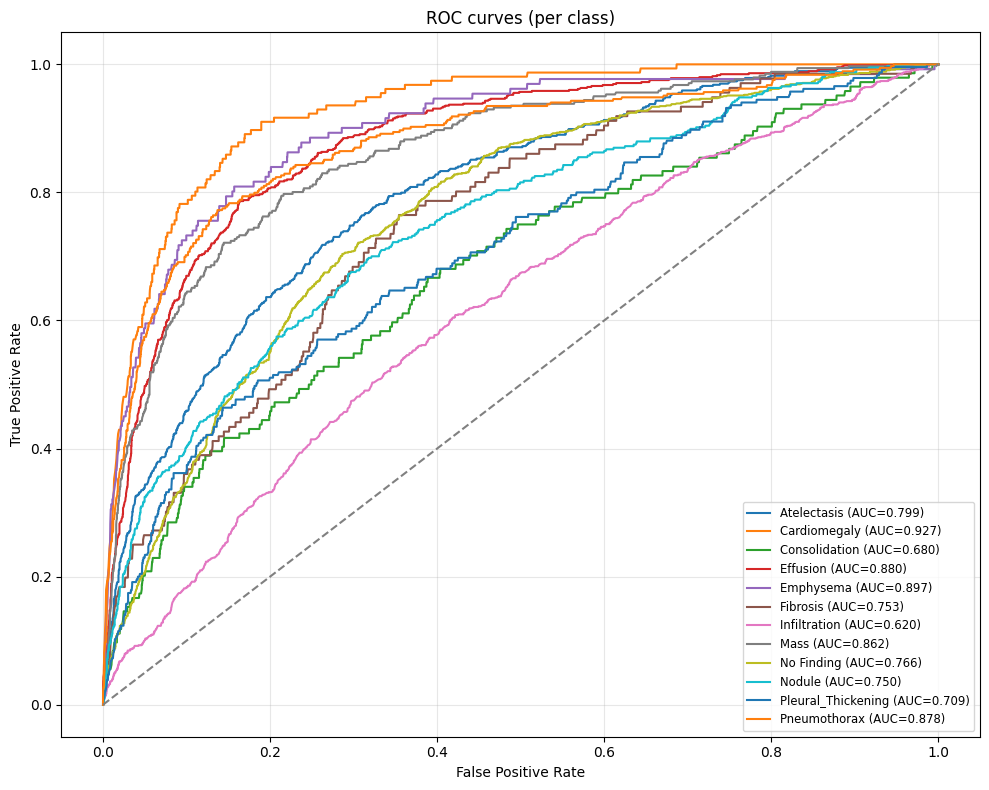

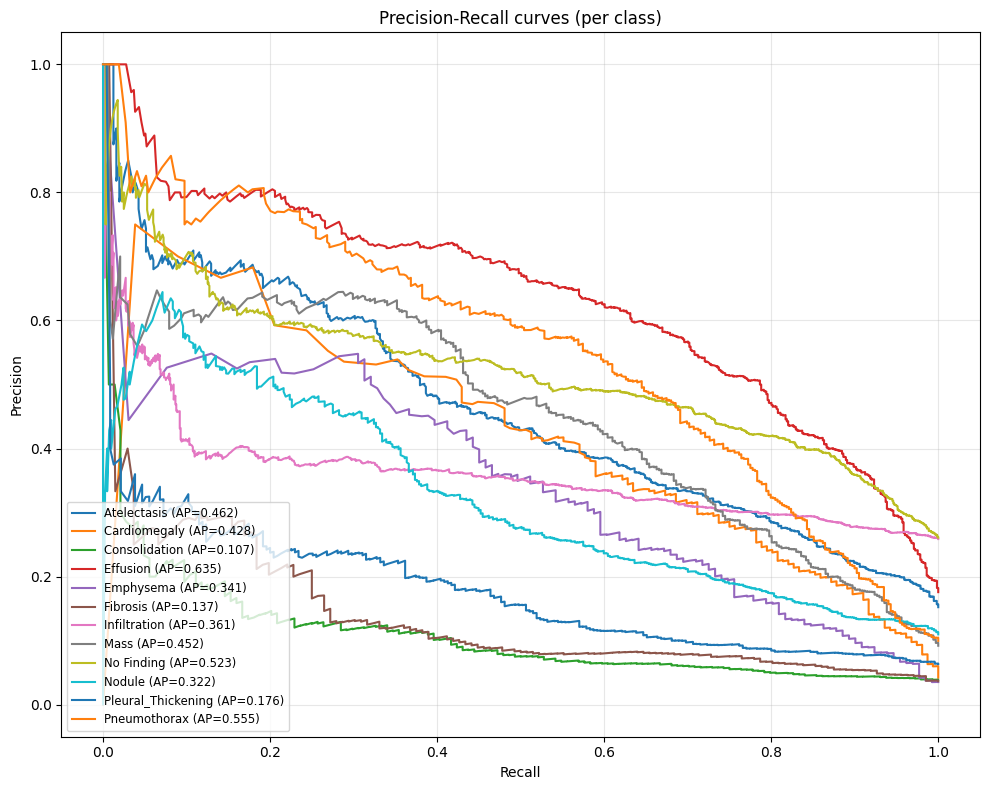


Saved metrics_table.csv to eval_plots


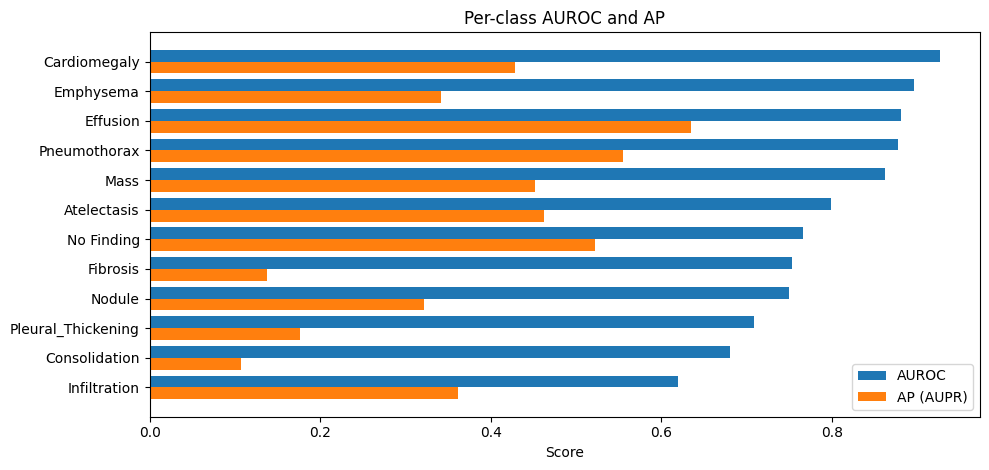


Per-class summary:
             label    AUROC       AP  best_threshold  best_f1  precision_at_bestT  recall_at_bestT
      Cardiomegaly 0.927101 0.428250            0.98 0.472222            0.416667         0.544872
         Emphysema 0.896596 0.341076            0.98 0.424908            0.408451         0.442748
          Effusion 0.880426 0.635250            0.70 0.627697            0.573791         0.692780
      Pneumothorax 0.877577 0.555460            0.87 0.567604            0.560847         0.574526
              Mass 0.862476 0.451971            0.79 0.501873            0.436957         0.589443
       Atelectasis 0.799060 0.461975            0.68 0.470021            0.384442         0.604610
        No Finding 0.766292 0.522660            0.35 0.557890            0.463381         0.700828
          Fibrosis 0.753209 0.137208            0.97 0.228188            0.209877         0.250000
            Nodule 0.749912 0.322107            0.83 0.377113            0.400552        

In [48]:
# === Visualization & evaluation utilities (run after you computed `probs` and `labs`) ===
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    precision_score, recall_score, f1_score,
    confusion_matrix
)

# Safety checks
assert 'probs' in globals() and 'labs' in globals(), "Run validation first to produce `probs` and `labs`."
assert probs.shape == labs.shape, "probs and labs must have same shape (N, C)."
C = probs.shape[1]
assert C == len(labels), "Length of labels list must equal number of classes."

out_dir = "eval_plots"
os.makedirs(out_dir, exist_ok=True)

# 1) ROC curves (all classes on one figure)
plt.figure(figsize=(10, 8))
for i, lab in enumerate(labels):
    try:
        fpr, tpr, _ = roc_curve(labs[:, i], probs[:, i])
        auc = roc_auc_score(labs[:, i], probs[:, i])
        plt.plot(fpr, tpr, label=f"{lab} (AUC={auc:.3f})")
    except ValueError:
        # only one class present in labels
        plt.plot([], [], label=f"{lab} (AUC=nan)")
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves (per class)")
plt.legend(loc='lower right', fontsize='small')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "roc_curves.png"), dpi=150)
plt.show()

# 2) PR curves (per class)
plt.figure(figsize=(10, 8))
for i, lab in enumerate(labels):
    try:
        prec, rec, _ = precision_recall_curve(labs[:, i], probs[:, i])
        ap = average_precision_score(labs[:, i], probs[:, i])
        plt.plot(rec, prec, label=f"{lab} (AP={ap:.3f})")
    except ValueError:
        plt.plot([], [], label=f"{lab} (AP=nan)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curves (per class)")
plt.legend(loc='lower left', fontsize='small')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "pr_curves.png"), dpi=150)
plt.show()

# 3) Compute AUROC and AP per class
aucs = []
aps = []
for i in range(C):
    try:
        aucs.append(float(roc_auc_score(labs[:, i], probs[:, i])))
    except Exception:
        aucs.append(float('nan'))
    try:
        aps.append(float(average_precision_score(labs[:, i], probs[:, i])))
    except Exception:
        aps.append(float('nan'))

# 4) Find per-class optimal threshold by maximizing F1 (grid search 0.00..1.00 by 0.01)
thresholds = np.linspace(0.0, 1.0, 101)
best_thresholds = []
best_f1s = []
best_precisions = []
best_recalls = []
for i in range(C):
    best_f1 = -1.0
    best_t = 0.5
    best_p, best_r = 0.0, 0.0
    y_true = labs[:, i].astype(int)
    y_prob = probs[:, i]
    # skip classes with no positives
    if y_true.sum() == 0:
        best_thresholds.append(float('nan'))
        best_f1s.append(float('nan'))
        best_precisions.append(float('nan'))
        best_recalls.append(float('nan'))
        continue
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        p = precision_score(y_true, y_pred, zero_division=0)
        r = recall_score(y_true, y_pred, zero_division=0)
        f = f1_score(y_true, y_pred, zero_division=0)
        if f > best_f1:
            best_f1 = f
            best_t = t
            best_p = p
            best_r = r
    best_thresholds.append(best_t)
    best_f1s.append(best_f1)
    best_precisions.append(best_p)
    best_recalls.append(best_r)

# 5) Save per-class confusion matrices (using best thresholds)
for i, lab in enumerate(labels):
    t = best_thresholds[i]
    if np.isnan(t):
        print(f"Skipping confusion matrix for {lab}: no positives in ground truth.")
        continue
    y_true = labs[:, i].astype(int)
    y_pred = (probs[:, i] >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    # build cm heatmap
    fig, ax = plt.subplots(figsize=(4,3))
    cm = np.array([[tn, fp],[fn, tp]])
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Pred 0','Pred 1']); ax.set_yticklabels(['True 0','True 1'])
    for (m,n), val in np.ndenumerate(cm):
        ax.text(n, m, f"{val}", ha='center', va='center', color='black', fontsize=12)
    ax.set_title(f"Confusion matrix: {lab}\n(thr={t:.2f})")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.tight_layout()
    fname = os.path.join(out_dir, f"cm_{lab.replace(' ','_')}.png")
    plt.savefig(fname, dpi=120)
    plt.close(fig)

# 6) Bar chart for AUROC and AP per class
df_metrics = pd.DataFrame({
    "label": labels,
    "AUROC": aucs,
    "AP": aps,
    "best_threshold": best_thresholds,
    "best_f1": best_f1s,
    "precision_at_bestT": best_precisions,
    "recall_at_bestT": best_recalls
})
df_metrics_sorted = df_metrics.sort_values("AUROC", ascending=False).reset_index(drop=True)
df_metrics_sorted.to_csv(os.path.join(out_dir, "metrics_table.csv"), index=False)
print("\nSaved metrics_table.csv to", out_dir)

# Plot AUROC and AP bars side-by-side
x = np.arange(len(df_metrics_sorted))
width = 0.4
plt.figure(figsize=(10, max(4, len(labels) * 0.4)))
plt.barh(x - width/2, df_metrics_sorted["AUROC"], height=width, label="AUROC")
plt.barh(x + width/2, df_metrics_sorted["AP"], height=width, label="AP (AUPR)")
plt.yticks(x, df_metrics_sorted["label"])
plt.xlabel("Score")
plt.title("Per-class AUROC and AP")
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "auroc_ap_bars.png"), dpi=150)
plt.show()

# 7) Print compact summary table (top lines)
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 120):
    print("\nPer-class summary:")
    print(df_metrics_sorted[["label","AUROC","AP","best_threshold","best_f1","precision_at_bestT","recall_at_bestT"]].to_string(index=False))

print(f"\nAll plots and CSV saved under: {os.path.abspath(out_dir)}")



Showing confusion matrix for: Atelectasis (thr=0.68)


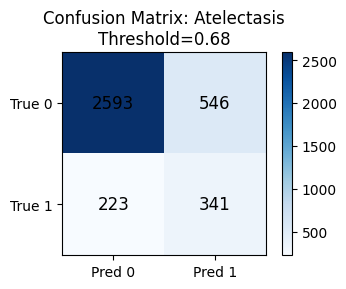


Showing confusion matrix for: Cardiomegaly (thr=0.98)


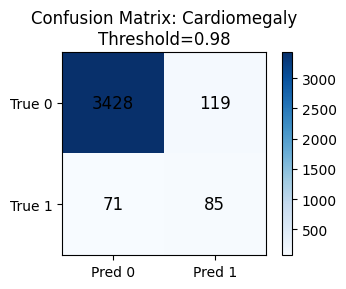


Showing confusion matrix for: Consolidation (thr=0.86)


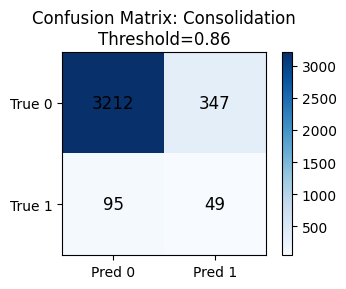


Showing confusion matrix for: Effusion (thr=0.70)


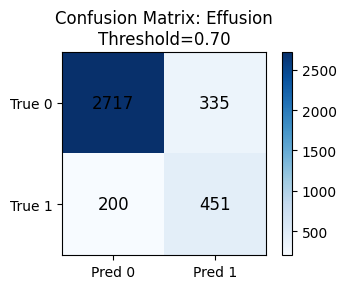


Showing confusion matrix for: Emphysema (thr=0.98)


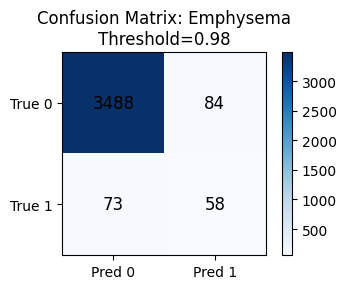


Showing confusion matrix for: Fibrosis (thr=0.97)


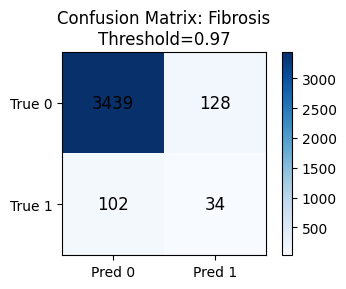


Showing confusion matrix for: Infiltration (thr=0.34)


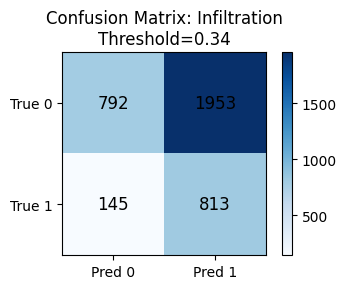


Showing confusion matrix for: Mass (thr=0.79)


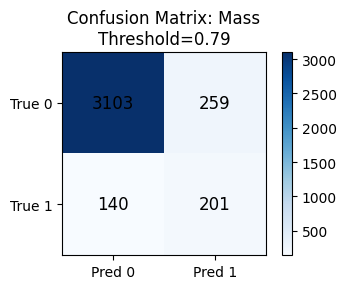


Showing confusion matrix for: No Finding (thr=0.35)


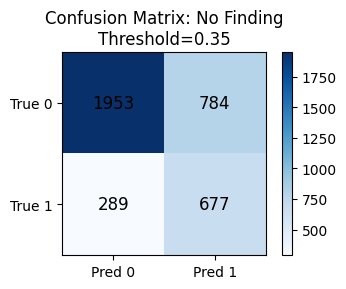


Showing confusion matrix for: Nodule (thr=0.83)


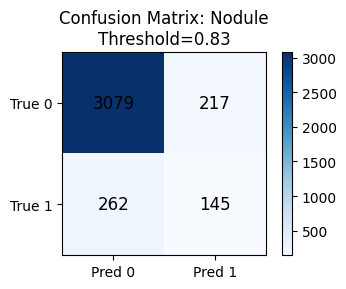


Showing confusion matrix for: Pleural_Thickening (thr=0.88)


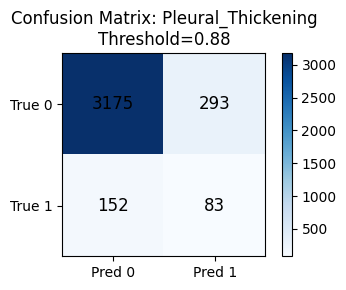


Showing confusion matrix for: Pneumothorax (thr=0.87)


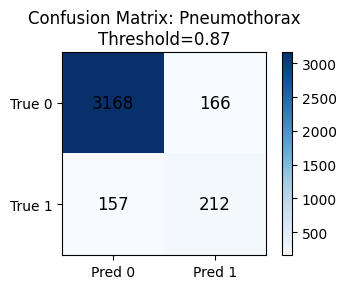

In [51]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix_single(y_true, y_prob, threshold, class_name):
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    cm = np.array([[tn, fp],[fn, tp]])

    fig, ax = plt.subplots(figsize=(4,3))
    im = ax.imshow(cm, cmap="Blues")

    ax.set_xticks([0,1])
    ax.set_yticks([0,1])
    ax.set_xticklabels(["Pred 0","Pred 1"])
    ax.set_yticklabels(["True 0","True 1"])

    ax.set_title(f"Confusion Matrix: {class_name}\nThreshold={threshold:.2f}")

    for (m, n), val in np.ndenumerate(cm):
        ax.text(n, m, f"{val}", ha="center", va="center", color="black", fontsize=12)

    plt.colorbar(im)
    plt.tight_layout()
    plt.show()


# ---- RUN THIS LOOP TO SHOW CONFUSION MATRIX FOR EVERY CLASS ----
for idx, lab in enumerate(labels):
    thr = best_thresholds[idx]
    print(f"\nShowing confusion matrix for: {lab} (thr={thr:.2f})")

    # Skip classes with no positive examples (AP / AUROC meaningless)
    if np.isnan(thr):
        print(f"Skipping {lab} — no positive samples in ground truth.")
        continue

    plot_confusion_matrix_single(
        labs[:, idx],     # ground truth for class
        probs[:, idx],    # probabilities for class
        thr,              # threshold for class
        lab               # class name
    )


In [54]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_curve, precision_score, recall_score, f1_score

P_target = 0.5   # minimum precision
R_min = 0.6    # minimum recall

chosen = []
rows = []

for i, lab in enumerate(labels):
    y_true = labs[:, i].astype(int)
    y_prob = probs[:, i]

    if y_true.sum() == 0:
        chosen.append(np.nan)
        rows.append({
            "label": lab,
            "chosen_threshold": np.nan,
            "precision": np.nan,
            "recall": np.nan,
            "f1": np.nan
        })
        continue

    precs, recs, ths = precision_recall_curve(y_true, y_prob)

    # 1) find all (precision >= P_target AND recall >= R_min)
    candidates = [(p, r, t) for p, r, t in zip(precs[:-1], recs[:-1], ths)
                  if p >= P_target and r >= R_min]

    if candidates:
        # pick candidate with highest recall (and precision second)
        best = max(candidates, key=lambda x: (x[1], x[0]))
        p_best, r_best, t_best = best
    else:
        # fallback: threshold that maximizes F1 while recall >= R_min
        best_f1 = -1
        t_best = 0.5
        p_best = 0
        r_best = 0
        for p, r, t in zip(precs[:-1], recs[:-1], ths):
            if r >= R_min:
                f = 2 * p * r / (p + r + 1e-12)
                if f > best_f1:
                    best_f1 = f
                    t_best = t
                    p_best = p
                    r_best = r

    chosen.append(t_best)
    rows.append({
        "label": lab,
        "chosen_threshold": float(t_best),
        "precision": float(p_best),
        "recall": float(r_best),
        "f1": float(2*p_best*r_best/(p_best+r_best+1e-12))
    })

df_thresh = pd.DataFrame(rows)
print("\n===== Final Selected Thresholds (Precision >= {:.2f}, Recall >= {:.2f}) =====\n".format(P_target, R_min))
print(df_thresh.to_string(index=False))



===== Final Selected Thresholds (Precision >= 0.50, Recall >= 0.60) =====

             label  chosen_threshold  precision   recall       f1
       Atelectasis          0.678223   0.384529 0.608156 0.471154
      Cardiomegaly          0.966797   0.362595 0.608974 0.454545
     Consolidation          0.219360   0.064865 0.666667 0.118227
          Effusion          0.570312   0.500000 0.788018 0.611807
         Emphysema          0.887207   0.269103 0.618321 0.375000
          Fibrosis          0.565918   0.082936 0.639706 0.146835
      Infiltration          0.341797   0.294737 0.847599 0.437382
              Mass          0.769531   0.422998 0.604106 0.497585
        No Finding          0.348877   0.464481 0.703934 0.559671
            Nodule          0.606445   0.236715 0.601966 0.339806
Pleural_Thickening          0.567871   0.115942 0.612766 0.194990
      Pneumothorax          0.800781   0.505308 0.644986 0.566667
